In [26]:
import pandas as pd

# Charger le fichier Parquet
df = pd.read_parquet('../data/processed/final_dataset.parquet')

# Sauvegarder en CSV
df.to_csv('../data/processed/final_dataset.csv', index=False)


In [27]:
import pandas as pd

df = pd.read_csv('../data/processed/final_dataset.csv')


In [28]:
# Liste des colonnes
print(df.columns)


Index(['customer_unique_id', 'product_id', 'customer_state', 'customer_city',
       'product_category_name_english', 'price', 'product_photos_qty',
       'product_weight_g', 'product_length_cm', 'product_height_cm',
       'product_width_cm', 'purchase_count', 'purchase_count_state',
       'cooc_score', 'recency_days', 'label'],
      dtype='object')


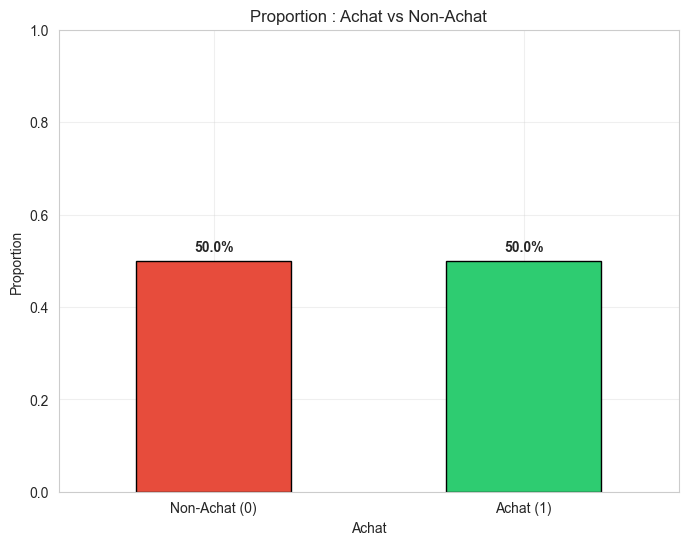

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
proportions = df['label'].value_counts(normalize=True)
proportions.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.xlabel('Achat')
plt.ylabel('Proportion')
plt.title('Proportion : Achat vs Non-Achat')
plt.xticks([0, 1], ['Non-Achat (0)', 'Achat (1)'], rotation=0)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
for i, v in enumerate(proportions):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
plt.show()

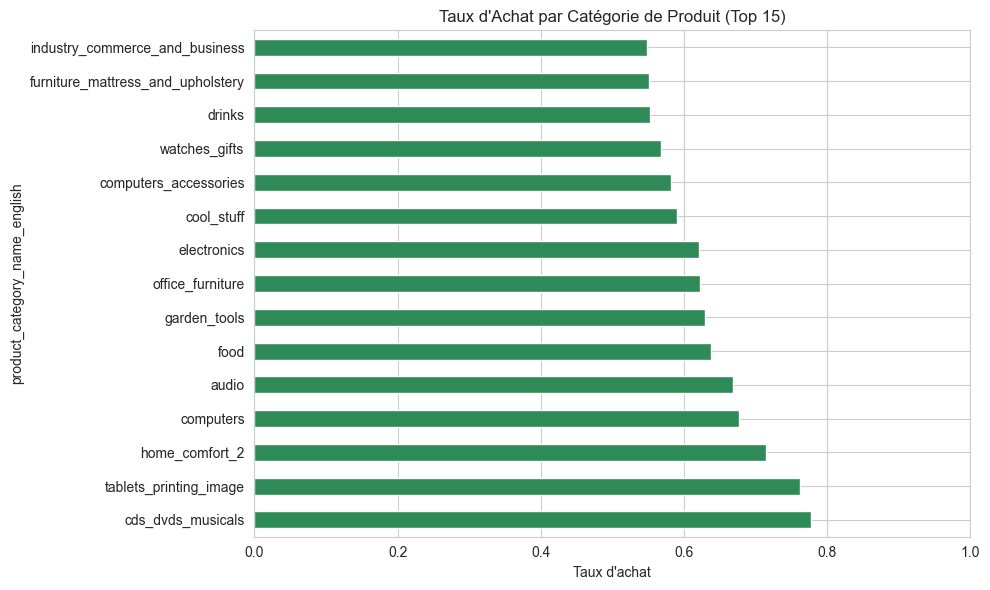

In [37]:
import matplotlib.pyplot as plt

cat_rate = df.groupby('product_category_name_english')['label'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
cat_rate.plot(kind='barh', color='seagreen')
plt.xlabel('Taux d\'achat')
plt.title('Taux d\'Achat par Catégorie de Produit (Top 15)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

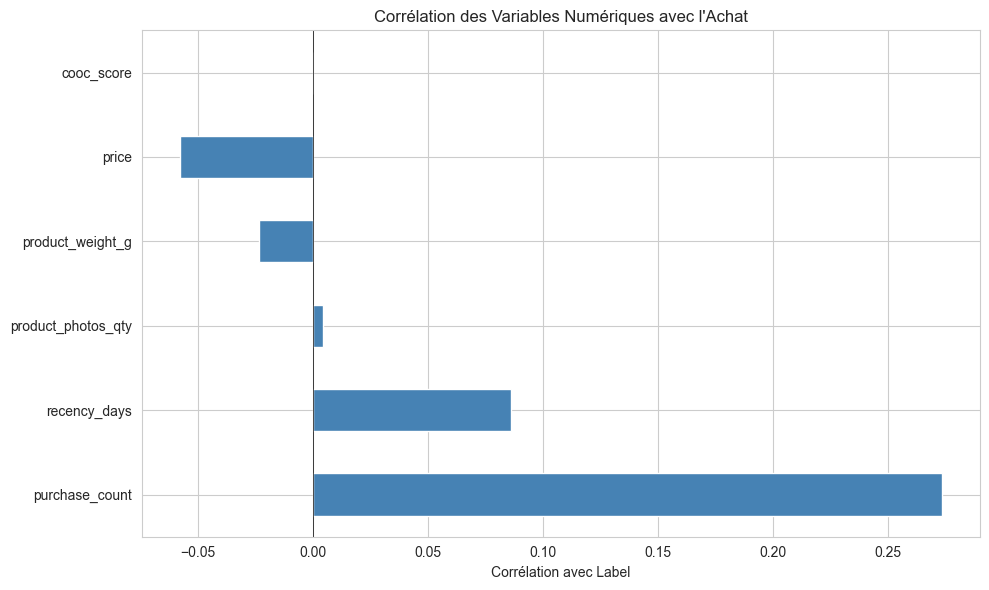

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['price', 'product_photos_qty', 'product_weight_g', 
                'purchase_count', 'recency_days', 'cooc_score', 'label']
corr = df[numeric_cols].corr()['label'].drop('label').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr.plot(kind='barh', color='steelblue')
plt.xlabel('Corrélation avec Label')
plt.title('Corrélation des Variables Numériques avec l\'Achat')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

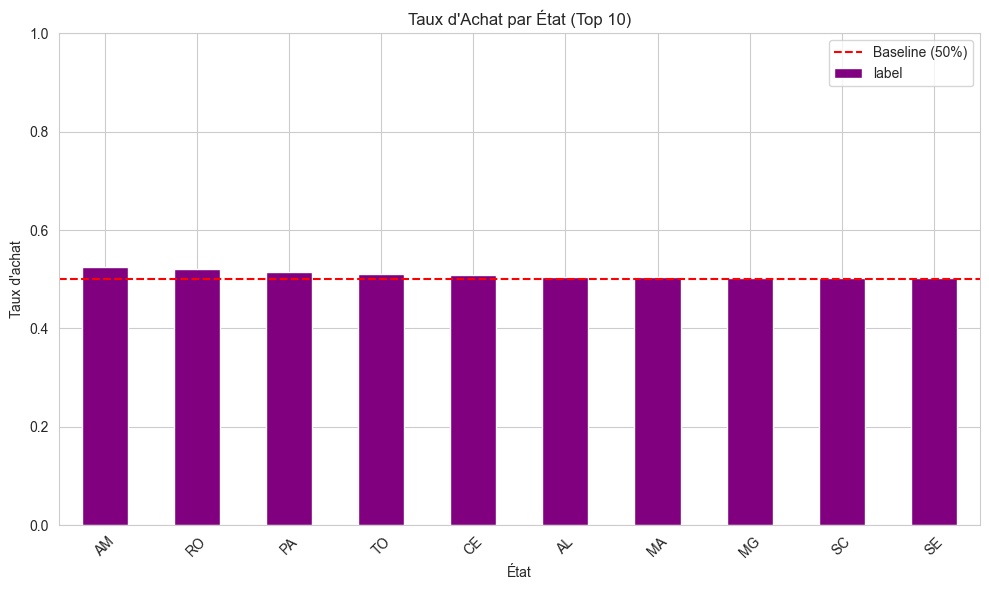

In [41]:
import matplotlib.pyplot as plt

state_rate = df.groupby('customer_state')['label'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
state_rate.plot(kind='bar', color='purple')
plt.xlabel('État')
plt.ylabel('Taux d\'achat')
plt.title('Taux d\'Achat par État (Top 10)')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='red', linestyle='--', label='Baseline (50%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()